# **Data Loading**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing

sns.set_style("whitegrid")

# as_frame=True returns a pandas DataFrame instead of raw numpy arrays
housing = fetch_california_housing(as_frame=True)
df = housing.frame

# Display the dataset
print("Shape:", df.shape)
print(df.head())

Shape: (20640, 9)
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


# **Data Exploration**

In [5]:
print("Basic info:")
print(df.info())

print("\nSummary statistics:")
print(df.describe().T)

print("\nMissing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB
None

Summary statistics:
               count         mean          std         min         25%  \
MedInc       20640.0     3.870671     1.899822    0.499900    2.563400   
HouseAge     20640.0    28.639486    12.585558    1.000000   18.000000   
AveRooms     20640.0     5.429000     2.474173    0.846154    4.440716   
AveBedrms    20640.0     1.096675     0.473911    0.3333

# **Data Quality Check**

In [6]:
# The target is capped — a survey artifact, not real prices
capped = (df["MedHouseVal"] >= 5.0).sum()
print(f"Records at the $500,001 cap: {capped}")

# Some ratio columns have physically implausible values
print("\nMax AveRooms:", df["AveRooms"].max())
print("Max AveOccup:", df["AveOccup"].max())
print("Blocks with AveRooms > 20:", (df["AveRooms"] > 20).sum())

Records at the $500,001 cap: 992

Max AveRooms: 141.9090909090909
Max AveOccup: 1243.3333333333333
Blocks with AveRooms > 20: 69


# **Visualization**

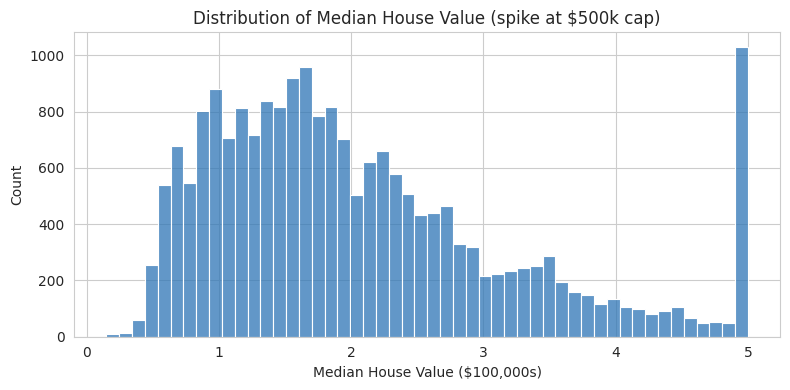

In [7]:
# Target distribution — the cap is visible as a spike at the right edge
plt.figure(figsize=(8,4))
sns.histplot(df["MedHouseVal"], bins=50, color="#2E75B6")
plt.title("Distribution of Median House Value (spike at $500k cap)")
plt.xlabel("Median House Value ($100,000s)")
plt.tight_layout()
plt.show()

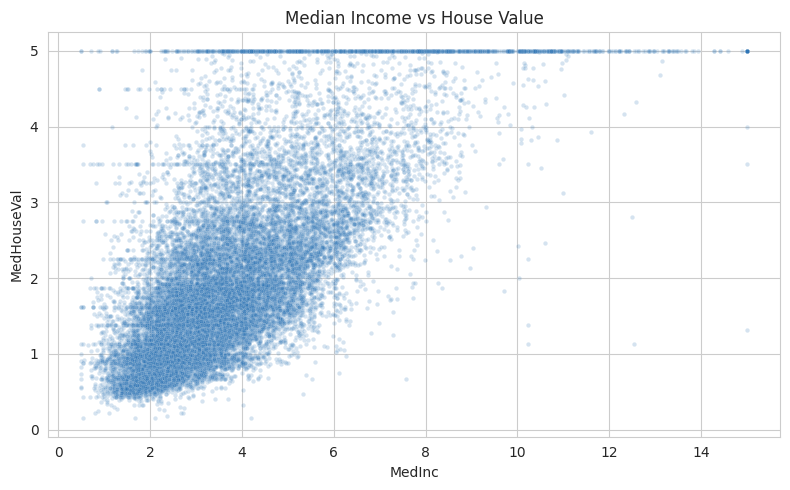

In [8]:
# Income vs price — the strongest single relationship
plt.figure(figsize=(8,5))
sns.scatterplot(x="MedInc", y="MedHouseVal", data=df, alpha=0.2, s=10, color="#2E75B6")
plt.title("Median Income vs House Value")
plt.tight_layout()
plt.show()

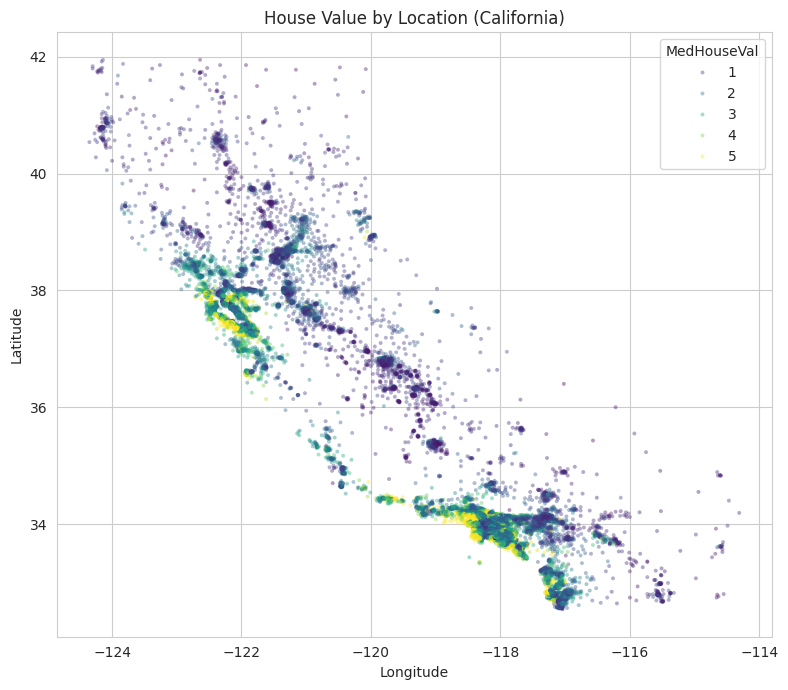

In [9]:
# Geographic price map
plt.figure(figsize=(8,7))
sns.scatterplot(x="Longitude", y="Latitude", hue="MedHouseVal",
                data=df, palette="viridis", alpha=0.4, s=8, edgecolor="none")
plt.title("House Value by Location (California)")
plt.tight_layout()
plt.show()

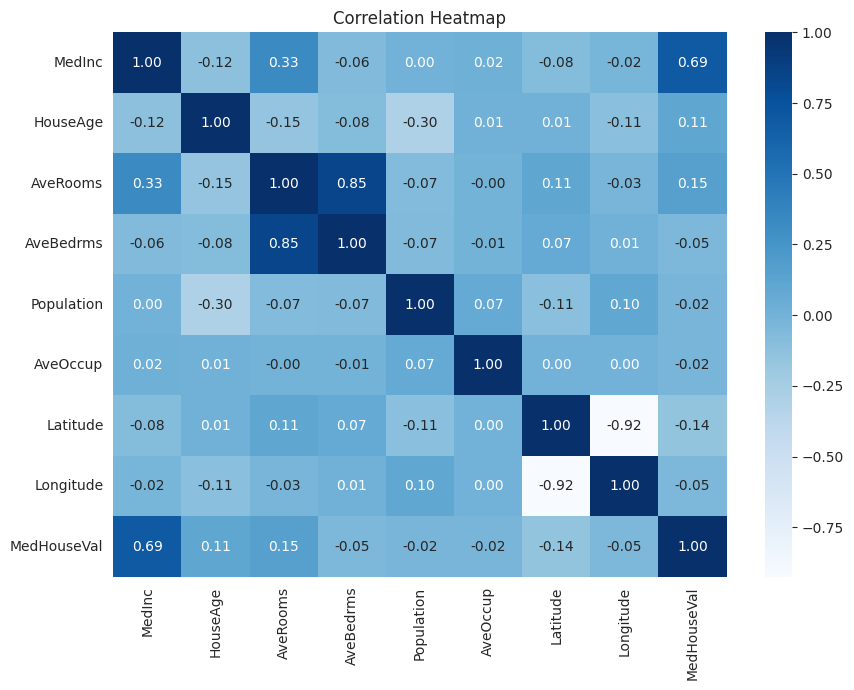

In [10]:
# Correlation heatmap
plt.figure(figsize=(9,7))
sns.heatmap(df.corr(), annot=True, cmap="Blues", fmt=".2f")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [11]:
# Correlation With Target
corr = df.corr()["MedHouseVal"].sort_values(ascending=False)
print(corr)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64


# **Cleaning**

In [12]:
before = len(df)

# 1. Remove implausible room ratios (institutions/resorts, not housing)
df = df[df["AveRooms"] < 20]

# 2. Remove capped target values — these are censored, not true prices
df = df[df["MedHouseVal"] < 5.0]

print(f"Rows removed: {before - len(df)}   Remaining: {len(df)}")

Rows removed: 1060   Remaining: 19580


# **Model Training**

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

FEATURES = ["MedInc", "HouseAge", "AveRooms", "Latitude", "Longitude"]

X = df[FEATURES]
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("Training set:", X_train.shape)
print("Test set:    ", X_test.shape)

model = LinearRegression()
model.fit(X_train, y_train)

print("\nCoefficients:")
for feat, coef in zip(FEATURES, model.coef_):
    print(f"  {feat:12s} {coef: .4f}")
print(f"  {'intercept':12s} {model.intercept_: .4f}")

Training set: (15664, 5)
Test set:     (3916, 5)

Coefficients:
  MedInc        0.3703
  HouseAge      0.0072
  AveRooms     -0.0157
  Latitude     -0.4082
  Longitude    -0.4209
  intercept    -35.3305


# **Model Evaluation**

In [14]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.4f}  (${rmse * 100000:,.0f})")
print(f"R²:   {r2:.4f}")

RMSE: 0.6288  ($62,875)
R²:   0.5873


# **Predicted Vs Actual**

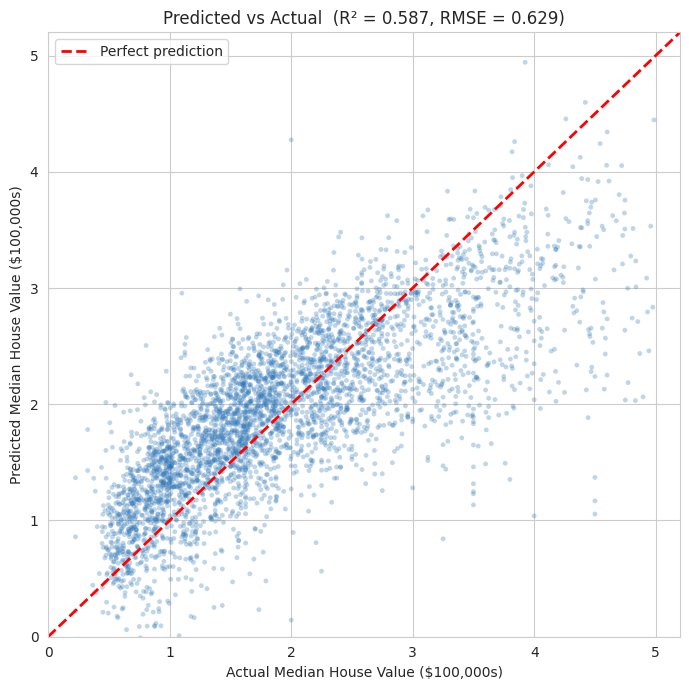

In [15]:
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.3, s=12, color="#2E75B6", edgecolor="none")

# Perfect-prediction reference line
lims = [0, 5.2]
plt.plot(lims, lims, "r--", lw=2, label="Perfect prediction")

plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual Median House Value ($100,000s)")
plt.ylabel("Predicted Median House Value ($100,000s)")
plt.title(f"Predicted vs Actual  (R² = {r2:.3f}, RMSE = {rmse:.3f})")
plt.legend()
plt.tight_layout(); plt.show()

## What Does R² = 0.587 Mean?

Think of house prices as varying a lot from neighbourhood to neighbourhood — some
cheap, some expensive. An R² of 0.587 means our model explains about **59% of that
variation** using just income, house size, age, and location. The remaining 41% is
driven by things the model can't see: school quality, crime rates, ocean views,
condition of the property, and so on.

In practical terms, the RMSE of 0.63 says our typical prediction is off by roughly
**63,000 dollars**. So if the model estimates a neighbourhood at $250,000, the real value
is usually somewhere around 190,000 – 310,000 dollars. That's useful for spotting broad
patterns, it will reliably tell you a wealthy coastal area costs more than an
inland rural one but it is nowhere near precise enough to price an individual
house. You'd want a real appraiser for that.